# FinanceGuard – Predicción de Churn Bancario
## Avance 1: Análisis Exploratorio (EDA) y Regresión Logística (Modelo Baseline)
### Contexto del negocio

FinanceGuard es un banco digital que actualmente cuenta con 10.000 clientes activos. En los últimos años, la institución ha observado un incremento preocupante en la tasa de abandono de clientes (churn), que alcanzó el 20% anual, generando pérdidas económicas significativas.

El objetivo estratégico es implementar un sistema de predicción que permita identificar a los clientes con mayor probabilidad de abandonar, de modo que el equipo de retención pueda aplicar acciones proactivas y reducir el churn al 15%.

## Objetivo de este notebook

### En este primer avance desarrollamos los componentes iniciales del proyecto, que incluyen:

Análisis Exploratorio de Datos (EDA)

Comprender la estructura y distribución de las variables.

Identificar patrones y factores potencialmente asociados al churn.

Detectar desbalanceos y comportamientos atípicos relevantes para el análisis.

Preparación de los datos

Limpieza básica.

Codificación de variables categóricas.

Escalado de variables numéricas.

División del dataset en subconjuntos de entrenamiento y prueba.

Entrenamiento del modelo baseline

Implementación de una Regresión Logística, el modelo lineal más utilizado en problemas de clasificación binaria.

Obtención de métricas iniciales de desempeño que servirán como referencia para modelos más complejos en avances posteriores.

## Importancia del EDA en el proyecto

### El EDA es una etapa crítica del proceso de Machine Learning. Permite:

Entender la naturaleza del problema.

Identificar relaciones entre variables que guiarán el modelado.

Detectar riesgos como multicolinealidad, distribuciones sesgadas o desbalance de clases.

Preparar una base sólida para aplicar algoritmos supervisados de forma correcta.

En este avance, el EDA nos ayudará a construir una comprensión profunda del comportamiento de los clientes y del fenómeno del churn, lo que será esencial para obtener modelos predictivos robustos.

## Tecnologías utilizadas

Python 3

Pandas y NumPy para manipulación de datos

Matplotlib y Seaborn para visualizaciones

Scikit-learn (Regresión Logística y utilidades de preprocesamiento)

Jupyter Notebook para desarrollo del flujo de trabajo


In [26]:
# 1. Importar librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')


# Configuración estética de gráficos
sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [27]:
# 2. Carga del dataset
df = pd.read_csv(r"C:\Users\Naty\OneDrive\Escritorio\DS MODULO 4\Churn_Modelling.csv")


print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [28]:
# 3. Exploración básica
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [29]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


### Variables principales del dataset

- **RowNumber, CustomerId, Surname**: identificadores (no se usarán como predictores).
- **CreditScore**: puntaje crediticio del cliente.
- **Geography**: país de residencia (France, Spain, Germany).
- **Gender**: género del cliente.
- **Age**: edad.
- **Tenure**: años que lleva como cliente del banco.
- **Balance**: saldo promedio en la cuenta.
- **NumOfProducts**: número de productos contratados.
- **HasCrCard**: indica si tiene tarjeta de crédito.
- **IsActiveMember**: indica si es un cliente activo.
- **EstimatedSalary**: salario estimado.
- **Exited**: variable objetivo (1 = churn, cliente que se fue; 0 = cliente activo).


In [30]:
# 4. Revisión de valores faltantes y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:", df.duplicated().sum())


Valores nulos por columna:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Registros duplicados: 0


In [31]:
df_limpio = df.copy()

# 1) Eliminar columnas que no aportan al modelado (IDs/nombres)
cols_drop = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df_limpio.columns]
df_limpio = df_limpio.drop(columns=cols_drop)

# 2) One-Hot Encoding para categóricas (si existen)
cat_cols = [c for c in ["Geography", "Gender"] if c in df_limpio.columns]
df_limpio = pd.get_dummies(df_limpio, columns=cat_cols, drop_first=True)

print("Shape final:", df_limpio.shape)
print("Columnas finales:", df_limpio.columns.tolist())


Shape final: (10000, 12)
Columnas finales: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [32]:
# Dataset final listo para modelado y clustering
df_limpio.to_csv("dataset_final_avance1.csv", index=False)


In [33]:
import os
os.listdir()


['1_EDA_Regresion_Logistica.ipynb',
 '2_GradientBoosting_Optimizacion.ipynb',
 '3_AprendizajeNoSupervisado.ipynb',
 'catboost_info',
 'Churn_Modelling (1).csv',
 'dataset_final_avance1.csv',
 'INSTALL.ipynb']

Conteo de clases (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Porcentaje de clases:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


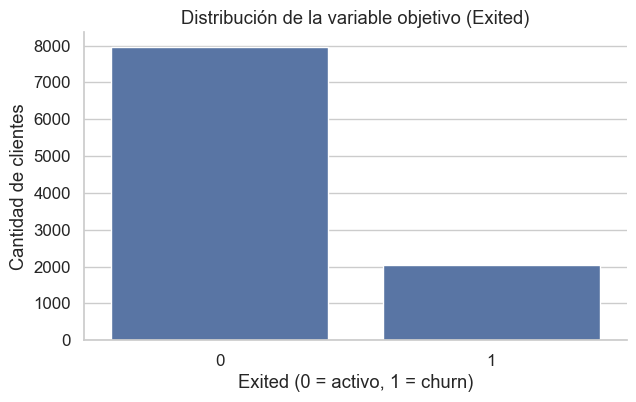

In [34]:
# 5. Análisis de la variable objetivo (churn)
churn_counts = df['Exited'].value_counts()
churn_percent = df['Exited'].value_counts(normalize=True) * 100

print("Conteo de clases (Exited):")
print(churn_counts)
print("\nPorcentaje de clases:")
print(churn_percent)

# Gráfico de barras
plt.figure()
sns.countplot(x='Exited', data=df)
plt.title('Distribución de la variable objetivo (Exited)')
plt.xlabel('Exited (0 = activo, 1 = churn)')
plt.ylabel('Cantidad de clientes')
plt.show()


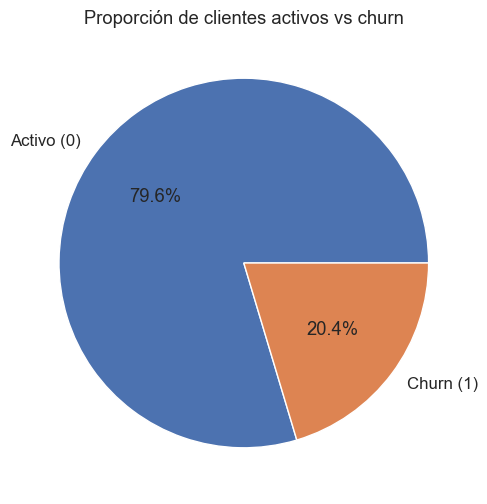

In [35]:
# Gráfico de torta de proporción de churn
plt.figure(figsize=(6, 6))
df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Activo (0)', 'Churn (1)'],
    colors=['#4C72B0', '#DD8452'],
    ylabel=''
)
plt.title('Proporción de clientes activos vs churn')
plt.show()


Observamos un fuerte desbalanceo en la variable objetivo: aproximadamente el 80% de los clientes permanecen activos y el 20% abandona. Este desbalanceo es típico en problemas de churn y será importante tenerlo en cuenta a la hora de entrenar modelos, especialmente para evaluar correctamente métricas como Recall y ROC-AUC.


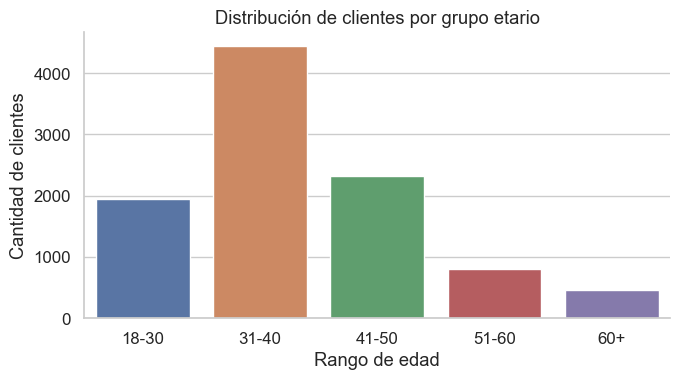

In [36]:
# Crear grupos etarios simples
df['Age_Group'] = pd.cut(df['Age'], 
                         bins=[18, 30, 40, 50, 60, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])

plt.figure()
sns.countplot(data=df, x='Age_Group', palette='deep')
plt.title('Distribución de clientes por grupo etario')
plt.xlabel('Rango de edad')
plt.ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()


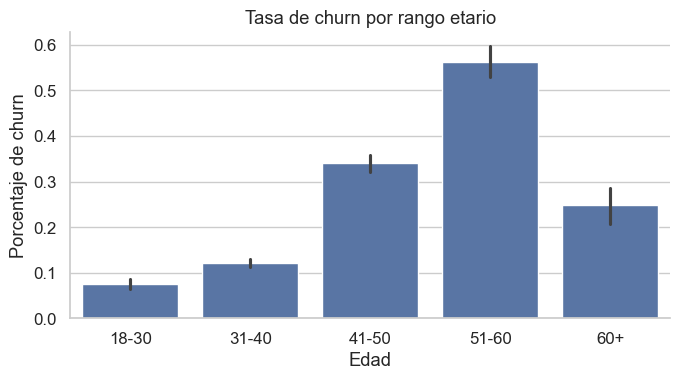

In [37]:
plt.figure()
sns.barplot(data=df, x='Age_Group', y='Exited', estimator='mean')
plt.title('Tasa de churn por rango etario')
plt.xlabel('Edad')
plt.ylabel('Porcentaje de churn')
plt.tight_layout()
plt.show()


La mayor parte de los clientes se concentra entre los 31 y 40 años.  
Al analizar el churn por rango etario, observamos que los clientes entre 51 y 60 años presentan la tasa de abandono más alta (superior al 50%), mientras que los más jóvenes (18–30) muestran tasas de churn muy bajas.  

Este patrón sugiere diferencias importantes en comportamiento y necesidades entre los grupos etarios. En particular, el segmento de 51–60 años debería ser una prioridad para las estrategias de retención del banco, dado su elevado riesgo de abandono.



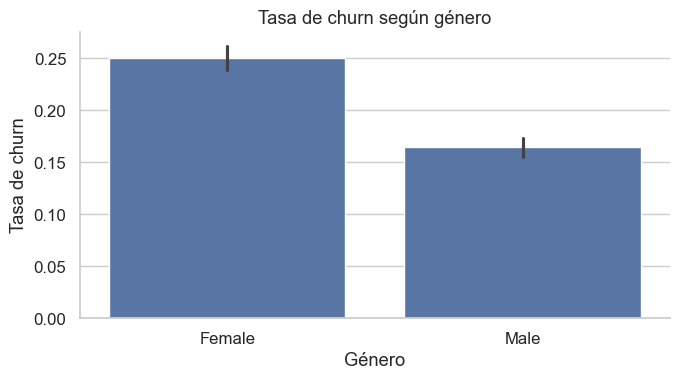

In [38]:
plt.figure()
sns.barplot(data=df, x='Gender', y='Exited', estimator='mean')
plt.title('Tasa de churn según género')
plt.xlabel('Género')
plt.ylabel('Tasa de churn')
plt.tight_layout()
plt.show()


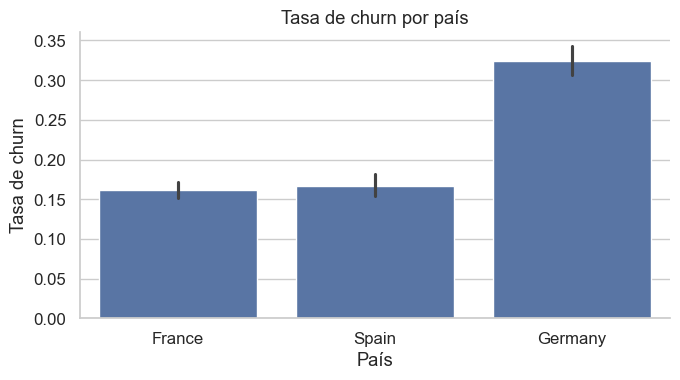

In [39]:
plt.figure()
sns.barplot(data=df, x='Geography', y='Exited', estimator='mean')
plt.title('Tasa de churn por país')
plt.xlabel('País')
plt.ylabel('Tasa de churn')
plt.tight_layout()
plt.show()


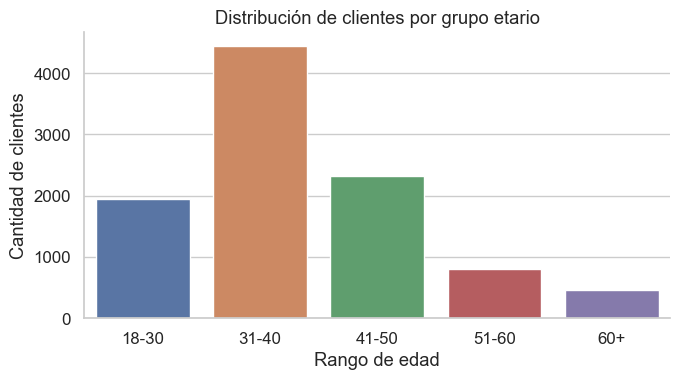

In [41]:
# Crear grupos etarios simples
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)

plt.figure()
sns.countplot(data=df, x='Age_Group', palette='deep')
plt.title('Distribución de clientes por grupo etario')
plt.xlabel('Rango de edad')
plt.ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()


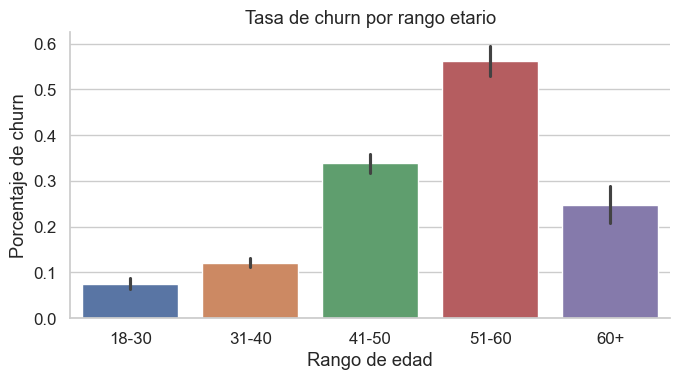

In [42]:
plt.figure()
sns.barplot(
    data=df,
    x='Age_Group',
    y='Exited',
    estimator='mean',
    palette='deep'
)

plt.title('Tasa de churn por rango etario')
plt.xlabel('Rango de edad')
plt.ylabel('Porcentaje de churn')
plt.tight_layout()
plt.show()


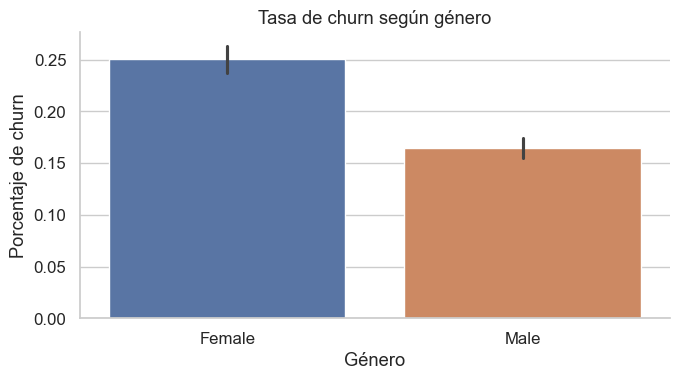

In [43]:
plt.figure()
sns.barplot(
    data=df,
    x='Gender',
    y='Exited',
    estimator='mean',
    palette='deep'
)

plt.title('Tasa de churn según género')
plt.xlabel('Género')
plt.ylabel('Porcentaje de churn')
plt.tight_layout()
plt.show()


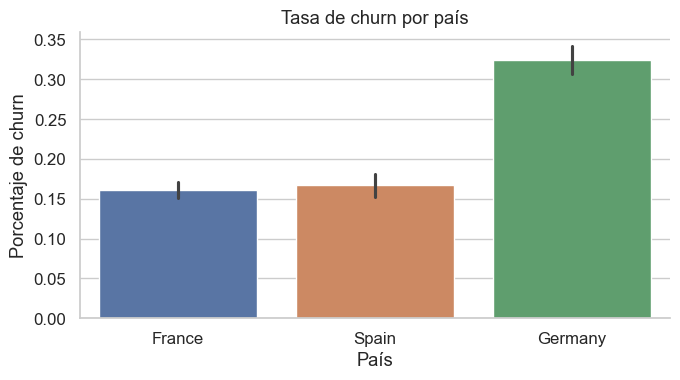

In [44]:
plt.figure()
sns.barplot(
    data=df,
    x='Geography',
    y='Exited',
    estimator='mean',
    palette='deep'
)

plt.title('Tasa de churn por país')
plt.xlabel('País')
plt.ylabel('Porcentaje de churn')
plt.tight_layout()
plt.show()


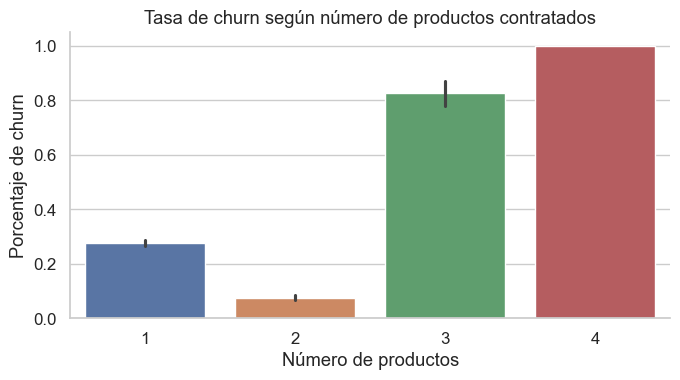

In [45]:
plt.figure()
sns.barplot(
    data=df,
    x='NumOfProducts',
    y='Exited',
    estimator='mean',
    palette='deep'
)

plt.title('Tasa de churn según número de productos contratados')
plt.xlabel('Número de productos')
plt.ylabel('Porcentaje de churn')
plt.tight_layout()
plt.show()



¿Los clientes que se van tienen más o menos dinero que los que se quedan?

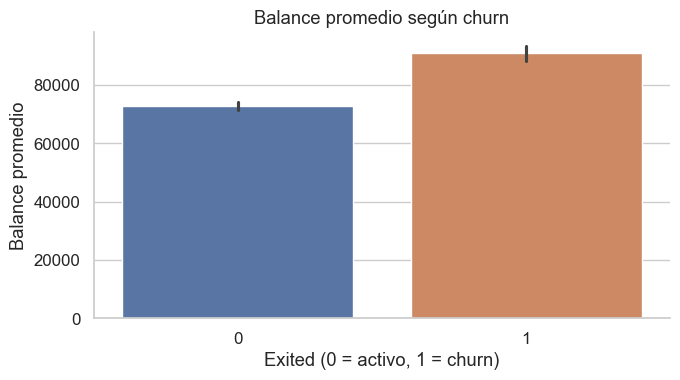

In [46]:
plt.figure()
sns.barplot(
    data=df,
    x='Exited',
    y='Balance',
    palette='deep'
)

plt.title('Balance promedio según churn')
plt.xlabel('Exited (0 = activo, 1 = churn)')
plt.ylabel('Balance promedio')
plt.tight_layout()
plt.show()


Este gráfico muestra que los clientes que abandonan el banco tienen un balance promedio mayor, lo que indica que el churn afecta a clientes valiosos y no solo a perfiles de bajo uso.

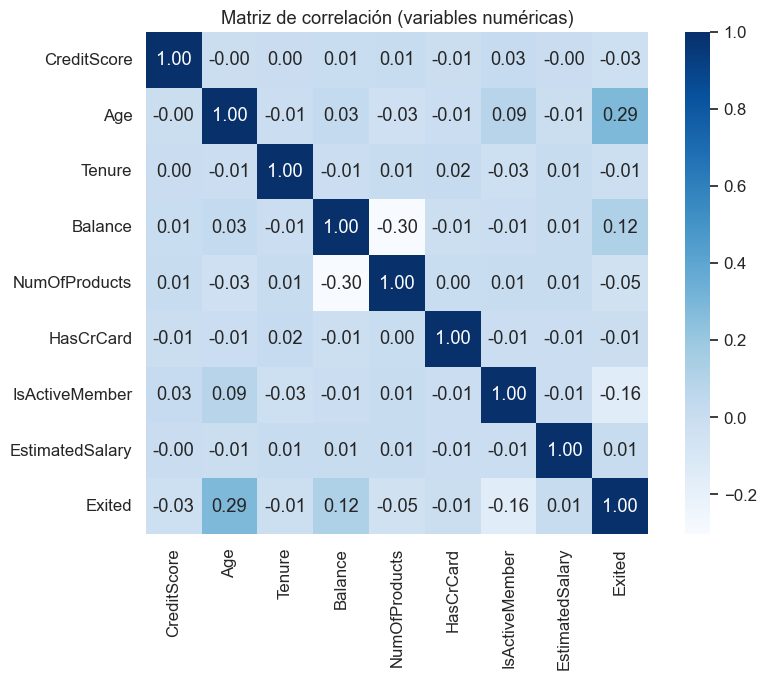

In [48]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember',
            'EstimatedSalary', 'Exited']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    square=True
)
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()


Age presenta la correlación positiva más alta con el churn (≈ 0.29), lo que sugiere que a mayor edad aumenta la probabilidad de abandono.

Balance muestra una correlación positiva moderada (≈ 0.12), indicando que los clientes con mayores saldos tienden a abandonar con mayor frecuencia.

IsActiveMember tiene una correlación negativa (≈ -0.16), lo que sugiere que ser un cliente activo reduce el riesgo de churn.

El resto de las variables presentan correlaciones cercanas a cero, lo que indica una relación débil o nula con la salida del cliente.

Desde el punto de vista del modelado, estos resultados son positivos, ya que validan la estabilidad del modelo de Regresión Logística y respaldan la interpretación de los coeficientes y Odds Ratios, al no existir dependencias lineales fuertes entre los predictores.

In [49]:
# Eliminación de columnas irrelevantes
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df_model.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50


In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])


In [51]:
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)

df_model.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,41-50,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,41-50,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,41-50,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,31-40,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,41-50,False,True


In [ ]:
# Si existe Age_Group, la borra
df_model = df_model.drop(columns=['Age_Group'], errors='ignore')


Convertimos la variable categórica *Gender* en valores numéricos utilizando LabelEncoder.  
Esto es necesario porque los modelos de Machine Learning no pueden trabajar directamente con texto.


Aplicamos One-Hot Encoding sobre la variable *Geography*, creando columnas binarias para cada país.  
Usamos `drop_first=True` para evitar multicolinealidad, ya que una categoría queda como referencia.


In [53]:
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


#### Definición de variables predictoras (X) y variable objetivo (y)

Separamos la variable objetivo *Exited*, que indica si el cliente abandonó el banco (1) o permaneció activo (0), del resto de las variables predictoras.  
Esta separación es necesaria para entrenar modelos supervisados de clasificación.

#### División del dataset en entrenamiento y prueba

Separé los datos en entrenamiento (80%) y prueba (20%) para entrenar el modelo de forma justa y evaluar su desempeño con información nueva, manteniendo la proporción real de clientes que abandonan y los que permanecen.

Esta división garantiza que el modelo aprenda correctamente durante el entrenamiento y que podamos evaluar su desempeño de forma justa sobre datos que no ha visto previamente.


## --------------------------------------------------------------  

#### Escalado de variables numéricas

La Regresión Logística es un modelo sensible a las diferencias de escala entre variables.  
Para evitar que variables con valores grandes (como Balance o EstimatedSalary) dominen el modelo, aplicamos `StandardScaler`, que transforma todas las variables numéricas a una misma escala con media 0 y desviación estándar 1.

Este paso mejora la estabilidad del modelo y acelera el proceso de entrenamiento.


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Detección de multicolinealidad (VIF)

Antes de entrenar el modelo, se analiza la multicolinealidad entre las variables predictoras utilizando el Factor de Inflación de la Varianza (VIF).  
Este análisis permite validar la estabilidad del modelo y la correcta interpretación de los coeficientes y Odds Ratios.


In [56]:
# Convertimos el set de entrenamiento escalado a DataFrame
X_vif = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_vif.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,1.058568,0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,-0.578313,-0.577735
1,0.913626,0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,1.729169,-0.577735
2,1.079274,-1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,1.729169,-0.577735
3,-0.929207,0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,-0.578313,-0.577735
4,0.427035,0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,1.729169,-0.577735


In [57]:
vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df.sort_values("VIF", ascending=False)


,Variable,VIF
9,Geography_Germany,1.340848
4,Balance,1.337182
10,Geography_Spain,1.126594
5,NumOfProducts,1.125593
2,Age,1.012386
7,IsActiveMember,1.010647
1,Gender,1.003361
3,Tenure,1.002479
6,HasCrCard,1.001757
8,EstimatedSalary,1.001499


**Conclusión del análisis VIF**

Los valores de VIF obtenidos se encuentran muy cercanos a 1 para todas las variables, lo que indica ausencia de multicolinealidad.  
Esto confirma que las variables aportan información independiente y valida la correcta interpretación de los coeficientes y Odds Ratios del modelo de Regresión Logística.


In [58]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    solver='liblinear',
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Entrenamiento del modelo de Regresión Logística

Se entrena un modelo de Regresión Logística como modelo baseline, debido a su simplicidad, interpretabilidad y buen desempeño en problemas de clasificación binaria como el churn bancario.

In [59]:
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


Se generan las predicciones binarias y las probabilidades de churn sobre el conjunto de prueba.


In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



Se evalúa el desempeño del modelo mediante métricas de clasificación, con especial atención al Recall de la clase churn.


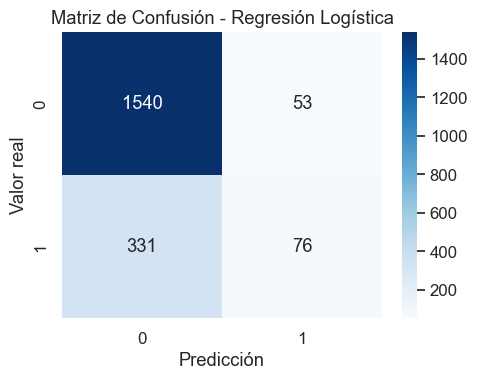

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()


Este gráfico muestra cómo se comporta el modelo al clasificar a los clientes entre: Cliente activo (0) Cliente que hace churn(1)

La matriz compara el valor real (lo que realmente ocurrió) y Predicción del modelo (lo que el modelo estimó)

 Interpretación de cada cuadrante
Predicción 0	Predicción 1
Real 0	1540	53
Real 1	331	    76
 Verdaderos Negativos (1540)

Clientes activos correctamente identificados como activos.
 El modelo funciona muy bien para reconocer clientes que no se van.
Falsos Positivos (53)
Clientes activos que el modelo predijo como churn.
Son alertas innecesarias, pero con bajo impacto operativo.
Falsos Negativos (331)
Clientes que sí abandonaron, pero el modelo los predijo como activos.
 Este es el error más crítico, porque el banco pierde la oportunidad de retenerlos.
Verdaderos Positivos (76)
Clientes que abandonaron y el modelo detectó correctamente.
 El modelo logra identificar una parte de los churners, pero aún hay margen de mejora.

El modelo es muy bueno detectando clientes activos

Tiene dificultades para detectar todos los churners, lo cual es esperable en datasets desbalanceados

Esto explica por qué métricas como Recall y ROC-AUC son más importantes que la accuracy en este problema.

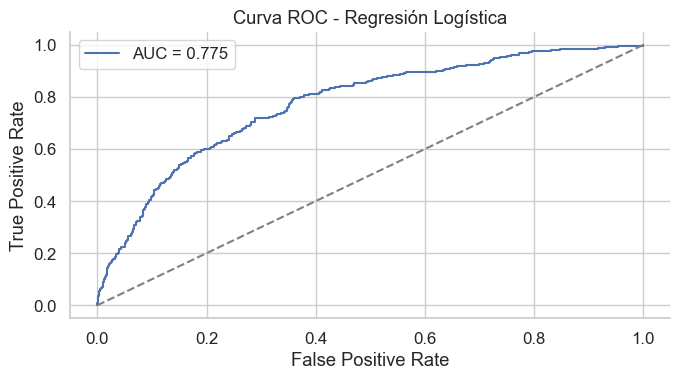

ROC-AUC: 0.7747701476515035


In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.tight_layout()
plt.show()

print("ROC-AUC:", auc)


La curva ROC y el valor AUC permiten evaluar la capacidad discriminatoria del modelo. 
Este valor se utilizará como baseline para comparar modelos más complejos en los próximos avances.


La matriz de confusión muestra que el modelo clasifica correctamente a la mayoría de los clientes activos, aunque presenta una menor capacidad para detectar clientes que abandonan el banco. Este comportamiento es consistente con el desbalance de clases presente en el dataset y refuerza la necesidad de evaluar métricas adicionales como ROC-AUC.


El modelo de Regresión Logística alcanza un valor de ROC-AUC de 0.775, lo que indica una buena capacidad para discriminar entre clientes que abandonan y clientes que permanecen activos. Este resultado se utilizará como modelo baseline para comparar el desempeño de modelos más complejos en avances posteriores.


In [63]:

odds_ratios = np.exp(log_reg.coef_[0])

odds_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Odds_Ratio': odds_ratios
}).sort_values(by='Odds_Ratio', ascending=False)

odds_df


,Variable,Odds_Ratio
2,Age,2.092388
9,Geography_Germany,1.428692
4,Balance,1.173760
8,EstimatedSalary,1.048873
10,Geography_Spain,1.019371
3,Tenure,0.980123
6,HasCrCard,0.968324
5,NumOfProducts,0.931932
0,CreditScore,0.917671
1,Gender,0.770535


Los Odds Ratios permiten interpretar el impacto de cada variable en la probabilidad de churn.  
Valores mayores a 1 indican un aumento en el riesgo de abandono, mientras que valores menores a 1 representan factores protectores.


El análisis de Odds Ratios muestra que la edad es el factor con mayor impacto en la probabilidad de churn, indicando que los clientes de mayor edad presentan un riesgo significativamente más alto de abandono. 

Asimismo, la ubicación geográfica en Alemania y un mayor balance se asocian con un incremento en el riesgo de churn. 

Por otro lado, variables como IsActiveMember actúan como factores protectores, reduciendo considerablemente la probabilidad de abandono, lo que resalta la importancia del engagement del cliente para estrategias de retención.


# ------------------------------------------------------------------------------------------- #

### Conclusión general del Avance 1

En este primer avance se desarrolló un modelo baseline de Regresión Logística para la predicción de churn bancario, con el objetivo de comprender los factores asociados al abandono de clientes y establecer una línea base de desempeño.

El modelo alcanzó un ROC-AUC de 0.775, lo que indica una buena capacidad para diferenciar entre clientes que abandonan el banco y clientes que permanecen activos.

Si bien el desempeño en la detección de churn se ve limitado por el desbalance de clases, el modelo resulta valioso desde el punto de vista interpretativo. Permite identificar variables clave asociadas al abandono, como la edad, la ubicación geográfica, el nivel de actividad del cliente y el balance promedio.

El análisis de multicolinealidad mediante el Factor de Inflación de la Varianza (VIF) mostró valores bajos para todas las variables predictoras, confirmando que no existe multicolinealidad severa y validando la estabilidad e interpretabilidad de los coeficientes del modelo.

En conclusión, este modelo baseline proporciona una base sólida tanto en desempeño como en interpretación, y servirá como punto de referencia para la implementación y comparación de modelos más complejos en los próximos avances del proyecto
